# LangGraph live optimization comparison across Trace / OTEL / sys.monitoring

This notebook runs the live comparison module and renders a shared analysis report.

- It uses the OpenRouter API when `OPENROUTER_API_KEY` is set.
- It defaults to `OPENROUTER_MODEL=google/gemini-3-flash-preview` when the model env var is absent.
- In CI or local runs without credentials, it prints a skip message and exits successfully.


## Optimization comparison

| config | runtime_s | baseline | best | gain | best_iteration | stability_std | score_history |
|---|---:|---:|---:|---:|---:|---:|---|
| trace | 54.513 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| trace+otel | 53.619 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| otel | 54.604 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| trace+sysmon | 54.634 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| trace+otel+sysmon | 53.552 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| otel+sysmon | 54.761 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |
| sysmon | 53.108 | 0.842 | 0.876 | 0.035 | 3 | 0.000 | [0.842, 0.842, 0.863, 0.876, 0.876, 0.876] |

## trace
- Runtime: `54.513s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

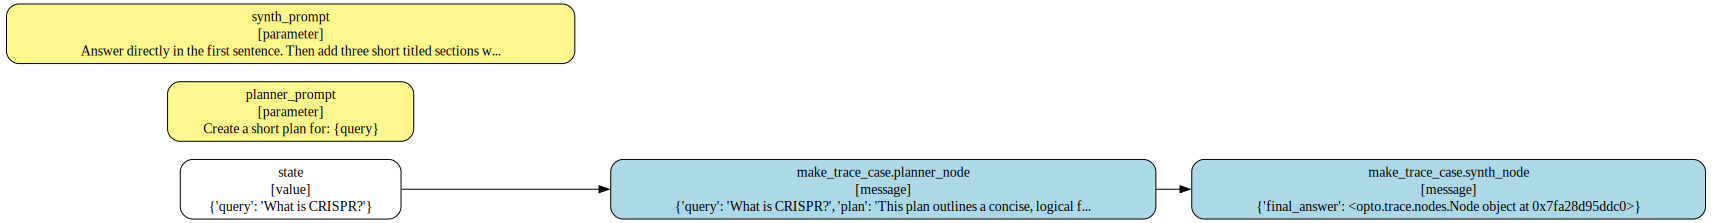

## trace+otel
- Runtime: `53.619s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

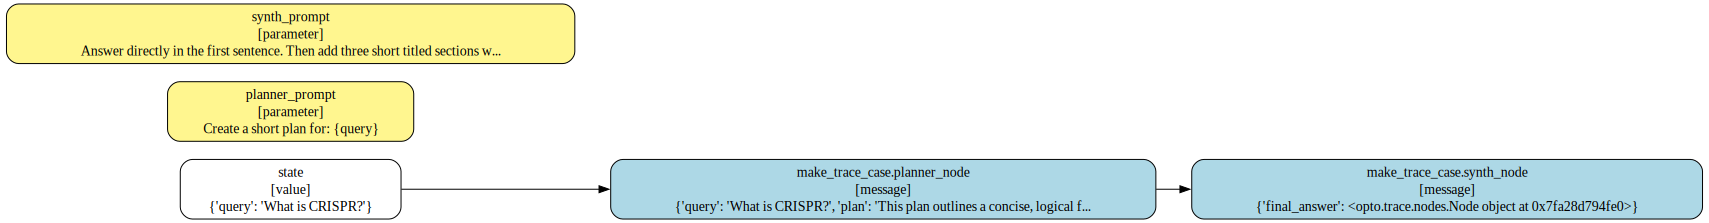

### observer otel
- Semantic message names: `[]`
- All message names: `[]`
- Parameter names: `[]`
- Span count: `0`
- Span names: `[]`

```json
{}
```

## otel
- Runtime: `54.604s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

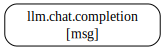

## trace+sysmon
- Runtime: `54.634s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

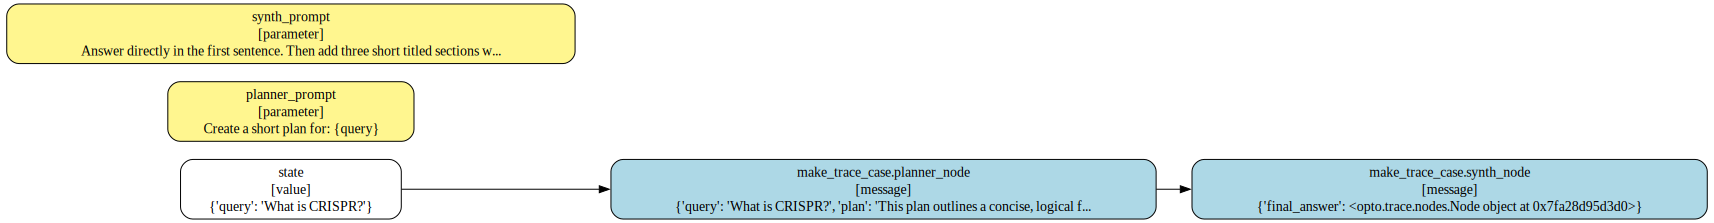

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

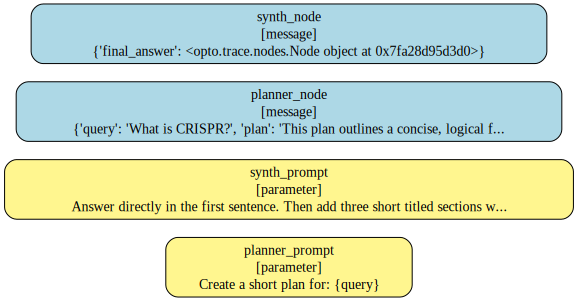

## trace+otel+sysmon
- Runtime: `53.552s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

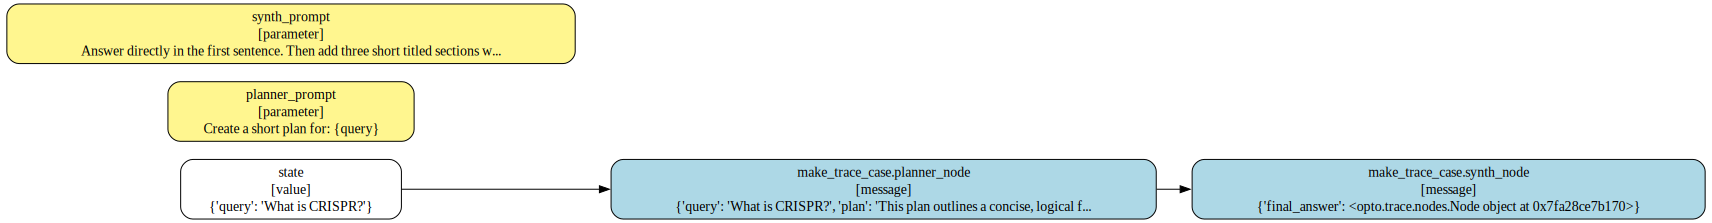

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

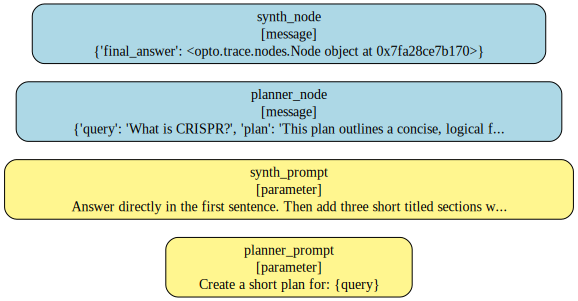

### observer otel
- Semantic message names: `[]`
- All message names: `[]`
- Parameter names: `[]`
- Span count: `0`
- Span names: `[]`

```json
{}
```

## otel+sysmon
- Runtime: `54.761s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

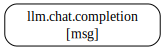

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

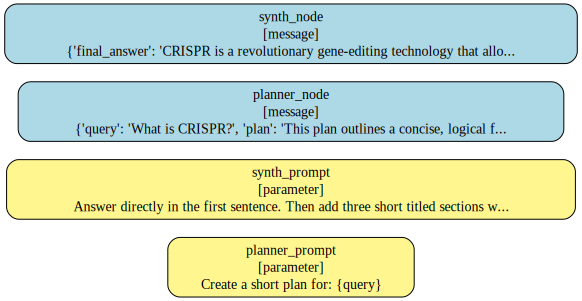

## sysmon
- Runtime: `53.108s`
- Baseline score: `0.842`
- Best score: `0.876`
- Score gain: `0.035`
- Best iteration: `3`
- Post-update stability std: `0.000`
- Score history: `[0.842, 0.842, 0.863, 0.876, 0.876, 0.876]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.

### **Mechanism: Molecular Scissors**
The system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to cut DNA, and a **guide RNA (gRNA)**, which is a pre-designed sequence that leads the enzyme to a specific genetic coordinate. Once the gRNA binds to the matching DNA sequence, Cas9 creates ...
```

### backend sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

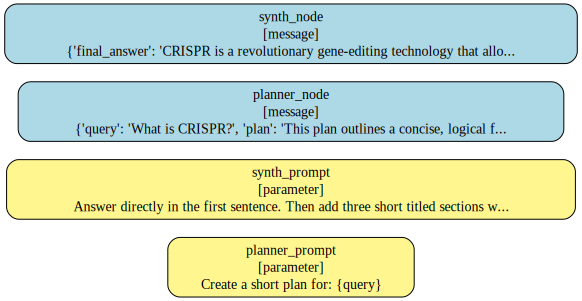

[{'config': 'trace',
  'runtime_s': 54.513,
  'baseline_score': 0.842,
  'best_score': 0.876,
  'score_gain': 0.035,
  'best_iteration': 3,
  'score_history': [0.842, 0.842, 0.863, 0.876, 0.876, 0.876],
  'stability_std': 0.0,
  'best_updates': {'synth_prompt': 'Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}'},
  'final_synth_prompt': 'Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}',
  'final_answer': 'CRISPR is a revolutionary gene-editing technology that allows scientists to precisely modify, delete, or replace specific sequences of DNA within a living organism.\n\n### **Mechanism: Molecular Scissors**\nThe system consists of two primary components: the **Cas9 enzyme**, which acts as molecular scissors to c

In [1]:
import importlib.util
from pathlib import Path

candidates = [
    Path('examples/notebooks/demo_langgraph_instrument_and_compare_observers.py'),
    Path('demo_langgraph_instrument_and_compare_observers.py'),
]

for candidate in candidates:
    if candidate.exists():
        spec = importlib.util.spec_from_file_location('compare_observers_demo', candidate)
        module = importlib.util.module_from_spec(spec)
        assert spec.loader is not None
        spec.loader.exec_module(module)
        rows = module.run_notebook_demo()
        break
else:
    raise FileNotFoundError('Could not locate demo_langgraph_instrument_and_compare_observers.py')

rows
